# Simulation for photonic components

## Fiber grating coupler

Let us design a *focusing* grating coupler for 
- $\lambda_0$ = 1550 nm
- SOI stack with 220 nm thickness
- 8 degree angle fiber

Constraints:
- Min spacing = 200 nm
- Min width = 200 nm


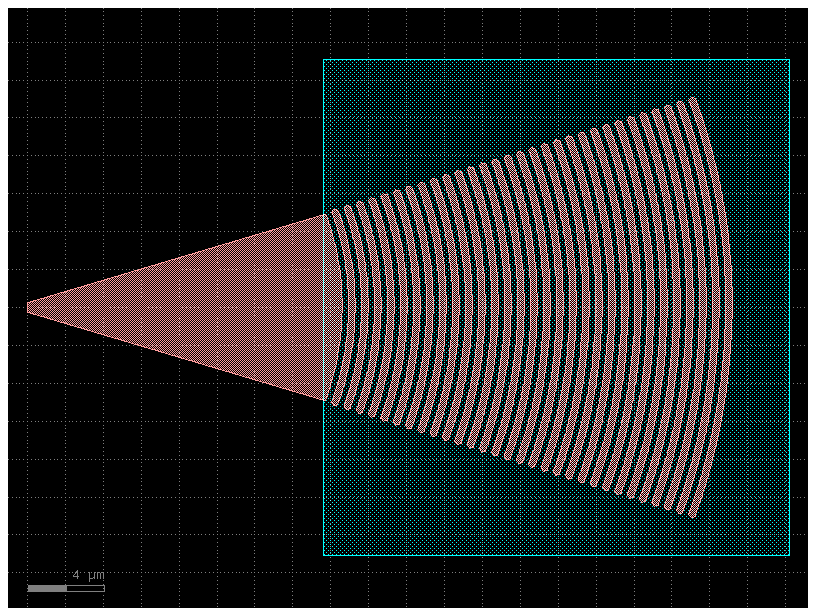

In [2]:
import gdsfactory as gf
gf.gpdk.PDK.activate()
gf.components.grating_coupler_elliptical()

### Parameters

The main figure of merit of a grating coupler is the insertion loss and its bandwidth $IL(\lambda)$.

There are many parameters that affect the performance of the GC. Let us consider only a *uniform* focusing grating coupler:

- Grating period $\Lambda$
- Grating line width $l_{g}$ (can be expressed also by the duty cycle $DC$)
- Number of periods $N_g$
- Fiber position in the in-plane
- Taper length $l_{taper}$ from waveguide input to first grating line
- Aperture $\Phi$
- Ellipticity $e$ of the grating lines

However, not all of them are relevant design parameters and it is possible to separate most of these parameters.
For example, the fiber position is not a design parameter because it will not change the shape of the transmission curve.

The main condition for diffraction can be satisfied considering only a 2D cross-section of the problem, removing the taper length, the aperture and the ellipticity out of the scope.

Finally, the number of periods has no optimum value, but it just needs has a lower boundary to cover the entire field.

To start, we can thus consider only the grating period and the line width as the starting parameters to optimize.


### Basic equations

Let us consider $x$ as the in-plane propagation direction.
The main equation is the Bragg grating condition that states

$$ 
k_{c,x} + G_x = k_{wg}
$$
where
- $k_{c,x} = \beta_c \sin(\theta)$ is the projection of the incident wavevector on the x-axis immersed in the cladding
- $k_{avg}$ is the average wavevector of the waveguide mode inside the grating
- $G_x = 2\pi/\Lambda$ is the grating vector with a periodicity of $\Lambda$ along the $x$ direction


This gives the starting point for the period
$$
\Lambda = \frac{\lambda}{n_{avg} - n_c \sin(\theta)}
$$

A common approximation for $n_{avg}$ for a grating with teeth is an arithmetic average between the effective index of the two slab modes

$$
n_{avg} = DC n_{1} + (1 - DC) n_{2}
$$
with $DC$ being the duty cycle and $n_{1,2}$ the effective index of the slab modes for the tooth and the etched part, respectively





In [81]:
import numpy as np

# ---- Input parameters ----- #
wl_0 = 1550 # Let us nm
n_c = 1.44  # Refractive index of glass
theta_deg = 8

## Grating parameters
dc = 0.5
n_wg = 2.847  # To be found from simulation
n_trench = 2.538  # To be found from simulation


def grating_period(wl, theta, n_c, n_avg):
    return np.abs(wl / (n_avg - n_c * np.sin(np.deg2rad(theta))))

def average_effective_index(n1, n2, x):
    return x * n1 + (1 - x) * n2

grating_period(wl_0, theta_deg, n_c, average_effective_index(n_wg, n_trench, dc))

np.float64(621.9677231125772)

### Slab mode simulations

A better estimation comes by doing a simulation of the waveguide modes, so that is what we are going to do in the next section using Tidy3D
Because we are considering a 2D problem, we need to find the slab modes of the waveguides and not the fully confined mode. This leads us to a 1D problem.



In [1]:
# standard python imports
import matplotlib.pylab as plt
import numpy as np

# tidy3D import
import tidy3d as td
from tidy3d.constants import C_0
from tidy3d.plugins.mode import ModeSolver

In [82]:
slab_modes = True

if slab_modes:
    Lx, Ly, Lz = 0, 0, 6  # 1D simulation
else:
    Lx, Ly, Lz = 6, 0, 6  # 2D simulation
# size of simulation domain
dl = 0.01

# --- refractive indices at 1550 nm -----------------------------------------
n_si   = 3.476
n_sio2 = 1.444
si   = td.Medium(permittivity=n_si**2,   name="Si")
sio2 = td.Medium(permittivity=n_sio2**2, name="SiO2")

# waveguide information
wg_width = 4
wg_height = 0.15

# central frequency
wl0 = 1.55  # In um
f0 = C_0 / wl0
df = f0 / 20
num_freqs = 3
f0_ind = num_freqs // 2
freqs = np.linspace(f0 - df / 2, f0 + df / 2, num_freqs)

# run_time in ps
run_time = 1e-11

# automatic grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=wl0)

waveguide = td.Structure(  # pyright: ignore[reportCallIssue]
    geometry=td.Box(size=(wg_width, td.inf, wg_height)),  # pyright: ignore[reportCallIssue]
    medium=si,
)



# now just set these in the boundary spec along the appropriate dimensions
bspec_pml_per = td.BoundarySpec(y=td.Boundary.periodic(),   # Propagation direction   # pyright: ignore[reportCallIssue]
                                x=td.Boundary.periodic() if slab_modes else td.Boundary.pml(), # in plane direction
                                z=td.Boundary.pml()) # Stack direction

sim = td.Simulation(  # pyright: ignore[reportCallIssue]
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    structures=[waveguide],
    medium=sio2,
    run_time=run_time,
    boundary_spec=bspec_pml_per,
)


plane = td.Box(center=(0, 0, 0), size=(5, 0, 4))
mode_spec = td.ModeSpec(
    num_modes=4,
)

mode_simulation = td.ModeSimulation.from_simulation(
    simulation=sim,
    plane=plane,
    mode_spec=mode_spec,
    freqs=freqs,
)

# sim.plot(y=0)
sim_data = mode_simulation.run_local()
mode_data = sim_data.modes


/workspace/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:42: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Ny, Ny)))
/workspace/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:55: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Ny, Ny)))


14:47:41 UTC WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 2, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 2, mode index 3 does not    
             decay at the plane boundaries.                                     

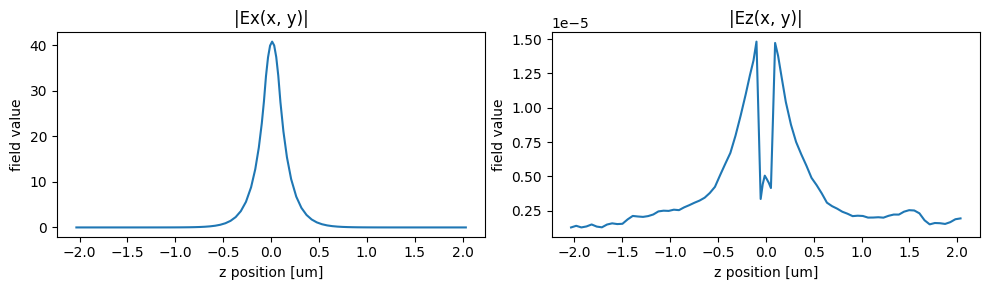

In [83]:
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
abs(mode_data.Ex.isel(mode_index=0, f=f0_ind)).plot(x="z", ax=ax1)
abs(mode_data.Ez.isel(mode_index=0, f=f0_ind)).plot(x="z", ax=ax2)

ax1.set_title("|Ex(x, y)|")
# ax1.set_aspect("equal")
ax2.set_title("|Ez(x, y)|")
# ax2.set_aspect("equal")
plt.show()

In [84]:
mode_data.to_dataframe()

wavelength     n eff  k eff  TE (Ex) fraction  \
f            mode_index                                                  
1.885791e+14 0             1.589744  2.523473    0.0      1.000000e+00   
             1             1.589744  1.603912    0.0      1.760971e-12   
             2             1.589744  1.436002    0.0      4.516383e-10   
             3             1.589744  1.424679    0.0      6.816052e-09   
1.934145e+14 0             1.550000  2.545475    0.0      1.000000e+00   
             1             1.550000  1.617392    0.0      1.141341e-11   
             2             1.550000  1.436474    0.0      2.000523e-11   
             3             1.550000  1.426123    0.0      7.979169e-11   
1.982499e+14 0             1.512195  2.566827    0.0      1.000000e+00   
             1             1.512195  1.631879    0.0      6.434456e-12   
             2             1.512195  1.436931    0.0      2.227665e-10   
             3             1.512195  1.427407    0.0      1.011123e-10   

                         wg TE fraction  wg TM fraction  mode area  
f            mode_index                                             
1.885791e+14 0                 1.000000        0.743072   0.298151  
             1                 0.820842        1.000000   0.808065  
             2                 0.991929        1.000000   3.192056  
             3                 0.959469        1.000000   2.256982  
1.934145e+14 0                 1.000000        0.745585   0.289906  
             1                 0.809167        1.000000   0.763270  
             2                 0.992438        1.000000   3.200735  
             3                 0.963113        1.000000   2.263432  
1.982499e+14 0                 1.000000        0.748160   0.282247  
             1                 0.797151        1.000000   0.722323  
             2                 0.992911        1.000000   3.211291  
             3                 0.966321        1.000000   2.272505

With these values, we can finally find the starting point for our simulations

In [85]:
n_wg = 2.850
n_trench = 2.545
grating_period(wl_0, theta_deg, n_c, average_effective_index(n_wg, n_trench, dc))

np.float64(620.7223384045045)

### 2D simulation of the grating coupler

Once we have a starting point $\Lambda_0$ and $DC_0$, we are going to sweep two parameters:
- period $\Lambda$
- duty cycle $DC$

Let us confirm the result with a 2D simulation.

We first build a simple grating coupler using GDSFactory to easily create the geometry.

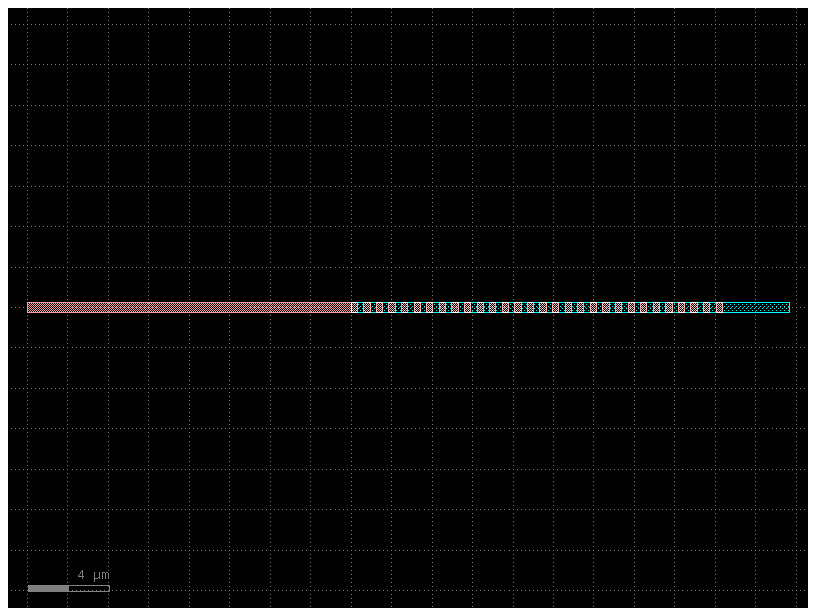

In [112]:
import gdsfactory as gf
gf.clear_cache()


@gf.cell
def simple_grating(period, duty_cycle=0.5, n_periods=30, taper_length = 16, cross_section="strip", layer_slab = "SLAB150",):

    xs = gf.get_cross_section(cross_section)

    wg_width = xs.width
    layer = xs.layer

    c = gf.Component()
    grating_length = (n_periods) * period
    wg = c << gf.components.straight(length=taper_length)

    line_width = duty_cycle * period
    tooth_poly = np.array([
        (0., -wg_width/2),
        (0., wg_width/2),
        (line_width, wg_width/2),
        (line_width, -wg_width/2),
    ])

    for p in range(n_periods):
        v = np.array([taper_length + p * period, 0])
        c.add_polygon(tooth_poly + v, layer=layer)

    # c.add_port(
    #     name="o1",
    #     center=(0, 0),
    #     width=wg_width,
    #     orientation=180,
    #     port_type="optical",
    # )
    c.add_ports([wg.ports["o1"]])

    if layer_slab is not None:
        slab_poly = np.array([
            (0., -wg_width/2),
            (0., wg_width/2),
            (grating_length + 3, wg_width/2),
            (grating_length + 3, -wg_width/2),
        ])
        v = np.array([taper_length, 0])
        c.add_polygon(slab_poly + v, layer=layer_slab)

    c.add_port(
        name="o2",
        center=(0, 0),
        width=wg_width,
        orientation=180,
        layer=layer,
        port_type=f"vertical_te",
    )

    return c

gc = simple_grating(0.622)
gc


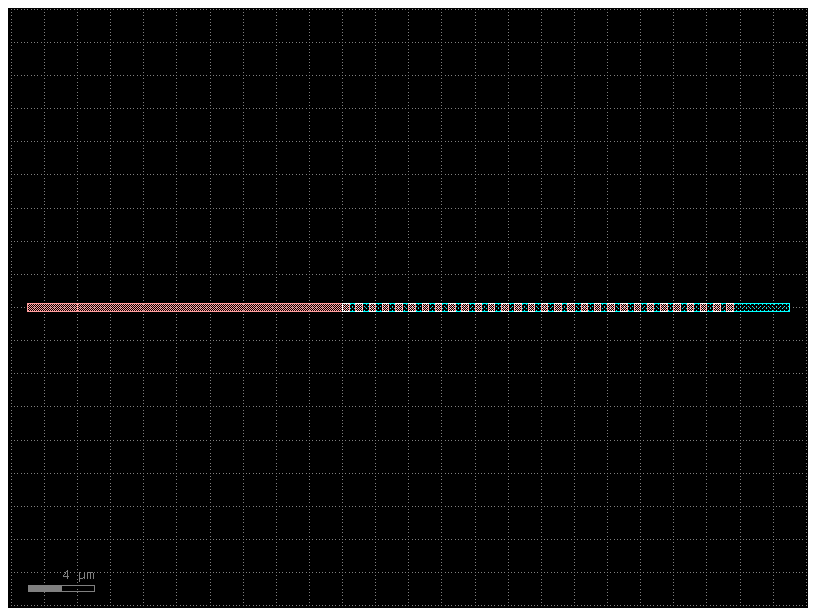

In [126]:
import gdsfactory as gf

# gf.clear_cache()

gf.gpdk.PDK.activate()



# @gf.cell
def create_grating_geometry(**grating_params):
    c = gf.Component()
    # gc = gf.components.grating_coupler_elliptical(grating_line_width=0.570 * 0.5,
    #                                               wavelength=1.55,                                    
    #                                               fiber_angle=8,
    # )
    gc = simple_grating(**grating_params)

    gc_r = c.add_ref(gc)
    s_r = c.add_ref(gf.components.straight(length=3))
    s_r.connect("o1", gc_r.ports["o1"])
    c.add_port("o2", port=s_r.ports["o2"])
    return c

c = create_grating_geometry(period=0.8, duty_cycle=0.5)
c

Now we can create the full simulation using MEEP

/workspace/.venv/lib/python3.12/site-packages/gsim/meep/simulation.py:713: UserWarning: Material 'Aluminum' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('Aluminum', refractive_index=...) to include it.
  material_data = resolve_materials(
/workspace/.venv/lib/python3.12/site-packages/gsim/meep/simulation.py:713: UserWarning: Material 'TiN' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('TiN', refractive_index=...) to include it.
  material_data = resolve_materials(
/workspace/.venv/lib/python3.12/site-packages/gsim/meep/simulation.py:713: UserWarning: Material 'ge' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('ge', refractive_index=...) to include it.
  material_data = resolve_materials(
/workspace/.venv/lib/python3.12/site-packages/gsim/meep/simulation.py:713: UserWarning: Material 'passive' has no optic

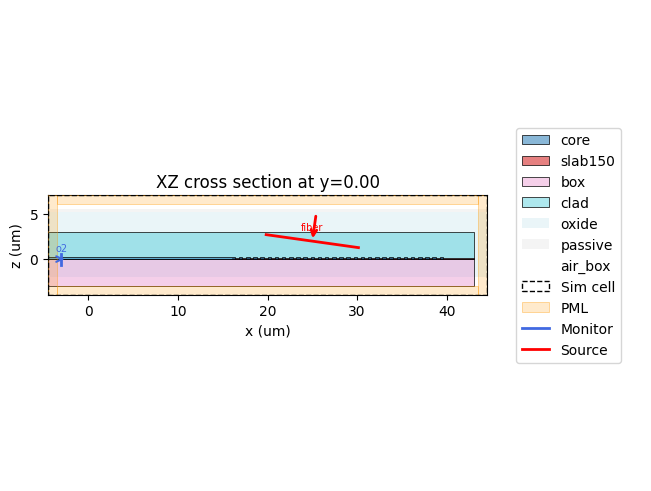

In [127]:
from gsim import meep
from gsim.common.stack import get_stack


def create_simulation(geometry_fn, geometry_params):
    stack = get_stack()  # auto-detects active PDK

    sim = meep.Simulation()

    c = geometry_fn(**geometry_params)

    sim.geometry(component=c, stack=stack)
    sim.materials = {"si": 3.48, "SiO2": 1.44}

    sim.solver(resolution=25, is_3d=False, plane="xz", save_animation=True)
    sim.solver.stop_when_energy_decayed()

    sim.source_fiber(
        x=25.0, z=2,
        angle_deg=-8.0,
        waist=5.2,
        wavelength=1.55,
        wavelength_span=0.06,
        polarization="TE",
    )


    sim.monitors = ["o2"]
    sim.domain(pml=1.0, margin=0.5)
    sim.num_freqs = 21

    # print(sim.validate_config())
    
    return sim

params = dict(period=0.8, duty_cycle=0.5)
sim = create_simulation(create_grating_geometry, params)
sim.plot_2d(slices="y")


And we are going to sweep the parameters

In [128]:
import pandas as pd

periods = np.arange(0.57, 0.62, 0.01)
duty_cycles = [0.4, 0.5, 0.6]

rows = []

for p in periods:
    for dc in duty_cycles:
        params = dict(period=p, duty_cycle=dc)
        sim = create_simulation(create_grating_geometry, params)
        result = sim.run()
        rows.append(
            {"period": p, "duty_cycle": dc, "result": result}
        )
# result.plot_interactive()

  meep-c042d166  completed  2m 21s
Extracting results.tar.gz...
Downloaded 325 files to /workspace/notebooks/sim-data-meep-c042d166


### Analysis
We are mostly interested in the peak insertion loss at the target wavelength, so let us extract it

In [155]:
def lin2db(x):
    return 20 * np.log10(np.abs(x))

def extract_peak_insertion_loss(result, wavelength=1.55, transform=None, sparam_key="S10"):
    transform = transform or lin2db

    idx = np.where(np.array(result.wavelengths) == wavelength)[0][0]

    v = result.s_params[sparam_key]
    mag = transform(v)
    return mag[idx]

# extract_peak_insertion_loss(rows[0]["result"])

df = pd.DataFrame(rows)
df["IL@1.55um"] = df["result"].apply(extract_peak_insertion_loss)
df


,period,duty_cycle,result,IL@1.55um
0,0.57,0.4,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-26.277826
1,0.57,0.5,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-19.864007
2,0.57,0.6,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-16.328056
3,0.58,0.4,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-19.744352
4,0.58,0.5,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-11.555001
5,0.58,0.6,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-7.313901
6,0.59,0.4,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-8.888294
7,0.59,0.5,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-5.396245
8,0.59,0.6,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-3.418854
9,0.60,0.4,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-4.093316


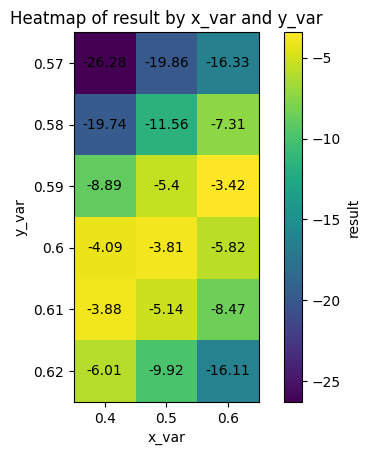

In [156]:
heatmap_data = df.pivot_table(
    index="period",
    columns="duty_cycle",
    values="IL@1.55um",
    # aggfunc="mean"
)

fig, ax = plt.subplots()

# Create heatmap
im = ax.imshow(heatmap_data.values)

# Axis labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Add values inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.values[i, j]
        ax.text(j, i, round(value, 2), ha="center", va="center")

# Add colorbar
plt.colorbar(im, ax=ax, label="result")

ax.set_xlabel("x_var")
ax.set_ylabel("y_var")
ax.set_title("Heatmap of result by x_var and y_var")

plt.show()

We can see that there is a clear trend and that the maximum is close to 600 nm period with a DC of 0.5.

> From here, we may refine our simulation or create an interpolation, but for the sake of demonstration we can finish with result

### Moving toward 3D simulation

We would like to confirm the simulation results obtained with the 2D simulation with a full 3D simulation. 
However, we can make some first estimations using heuristic models for the other parameters.

#### Number of periods
We can use a known formula for the *total grating length* used in Bragg reflector
$$
L_g = \frac{1}{\kappa_g} \approx \frac{\lambda/2}{n_{1} - n_{2}} 
$$
with $n_1$ and $n_2$ being the effective indices of the waveguides at two different thicknesses. 
From there then $N_g > L_g / \Lambda$


#### Aperture and focal length
Here we should chose the correct numerical aperture for the grating coupler.
We can consider the slab area between the input waveguide and the grating as a free-propagation region. Therefore, we can approximate the main mode of the waveguide with a Gaussian mode and use the Gaussian beam focus as guideline so

$$
NA \approx \frac{\lambda_0}{\pi w_{wg}}
$$
and then $\Phi \approx 2 * \arcsin(NA/n_{slab})$

The taper/free-propagation length should be chosen so that the mode expands to illuminate the required grating aperture with acceptable phase curvature and excess loss. Choose a focal length $f$ that gives the right numerical aperture.




#### Ellipticity
It is possible to demonstrate that, applying the Bragg grating condition over the plane instead of considering only one direction, that we can satisfy the condition if we design our gratings with grating lines having constant ellipticity $e$, with the result being

$$
e = \frac{n_c \sin(\theta)}{n_{avg}}
$$




## Splitter

For a broadband splitter 2x2 we need to use a multimode-interferometer, which they generally have more bandwidth than a directional coupler

### Basic equation for a MMI

An MMI essentially exploit the interference of multiple modes of a multi-mode waveguide to replicate an image after a certain distance.

A good result for the starting design is the beat length $L_{\pi}$ between the first two fundamental modes, such as

$$
L_{\pi} = \frac{\lambda/2}{n_0 - n_1}
$$
The problem then involves finding the effective indices of a waveguide with width $W$. From this equation alone is possible to understand why an MMI as a lower dependency on wavelength relative to a directional coupler. The beat length of a directional coupler is expressed with a similar equation but usually the $\Delta n$ between the symmetric and antisymmetric modes of a DC is much smaller, making it more sensitive to dispersion.

This characteristic length can be used to reach a specific function. In particular, exploiting the general interference, to have a 2x2 3dB splitter, the condition is
$$
L_{2x2} = \frac{3}{2}p L_{\pi}
$$
with $p$ being odd.

Let us first select a waveguide width $W$. The width needs to be chosen as a trade-off between low dispersion (larger $W$) and footprint.

In [104]:
import numpy as np
import tidy3d as td
from matplotlib import pyplot
from tidy3d.plugins import waveguide

# --- refractive indices at 1550 nm -----------------------------------------
n_si   = 3.476
n_sio2 = 1.444
si   = td.Medium(permittivity=n_si**2,   name="Si")
sio2 = td.Medium(permittivity=n_sio2**2, name="SiO2")

W = 5
wl0 = 1.55

strip = waveguide.RectangularDielectric(
    wavelength=wl0,
    core_width=W,
    core_thickness=0.22,
    core_medium=si,
    clad_medium=sio2,
    mode_spec=td.ModeSpec(num_modes=10, group_index_step=True),
)

# Take a look at the waveguide cross-section
strip.n_eff.values

c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tid

array([[2.90139651, 2.8890667 , 2.86840725, 2.83925104, 2.80135202,
        2.75437474, 2.69788313, 2.63131094, 2.55393672, 2.46483588]])

Now let us use the results for the waveguide solver to find the beat length

In [108]:

def beat_length(n0, n1, wl0=1.55):
    return (wl0/2) / (n0 - n1)

def mmi_2x2_length(Lpi, p=1):
    return 1.5 * p * Lpi


n0 = 2.901
n1 = 2.889
Lmmi = mmi_2x2_length(beat_length(n0, n1, wl0))

display(f"1st-order MMI 2x2 length = {Lmmi:.3f} um")

'1st-order MMI 2x2 length = 96.875 um'

### Eigenmode Expansion and MMI length sweep
Now, we need to verify this length, but to do that we need to use Eigenmode Expansion (EME). 

We will define a structure with an input waveguide and the MMI waveguide. Then we will sweep the length

In [1]:
import meow as mw
import numpy as np

length = 10.0
Lx, Ly, Lz = 10, 5, length

# Input parameter
t_si = 0.22
w_wg = 1.2
w_mmi = 5
s_wg = w_mmi/4


oxide = mw.Structure(
    material=mw.silicon_oxide,
    geometry=mw.Box(
        x_min=-Lx/2,
        x_max=Lx/2,
        y_min=-Ly/2,
        y_max=Ly/2,
        z_min=0.0,
        z_max=length + 2,
    ),
)

# Input waveguide
input_wg = mw.Structure(
    material=mw.silicon,
    geometry=mw.Box(
        x_min=-w_wg / 2 - s_wg,
        x_max=w_wg / 2 - s_wg,
        y_min=-t_si/2,
        y_max=t_si/2,
        z_min=0,
        z_max=1,
    ),
)

# MMI waveguide
mmi_wg = mw.Structure(
    material=mw.silicon,
    geometry=mw.Box(
        x_min=-w_mmi / 2,
        x_max=w_mmi / 2,
        y_min=-t_si/2,
        y_max=t_si/2,
        z_min=1,
        z_max=length + 1,
    ),
)

# Output waveguides
out1_wg  = mw.Structure(
    material=mw.silicon,
    geometry=mw.Box(
        x_min=-w_wg / 2 - s_wg,
        x_max=w_wg / 2 - s_wg,
        y_min=-t_si/2,
        y_max=t_si/2,
        z_min=length + 1,
        z_max=length + 2,
    ),
)

out2_wg  = mw.Structure(
    material=mw.silicon,
    geometry=mw.Box(
        x_min=-w_wg / 2 + s_wg,
        x_max=w_wg / 2 + s_wg,
        y_min=-t_si/2,
        y_max=t_si/2,
        z_min=length + 1,
        z_max=length + 2,
    ),
)

structures = [oxide, input_wg, mmi_wg, out1_wg, out2_wg]
# mw.visualize(structures)



We simply need to create 3 cells, for the input waveguide, the MMI, and the output waveguides

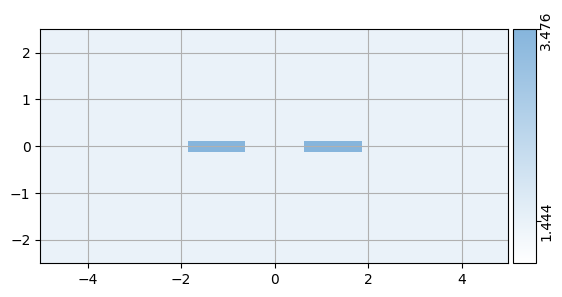

In [2]:
num_cells = 3

cells = mw.create_cells(
    structures=structures,
    mesh=mw.Mesh2D(
        x=np.linspace(-Lx/2, Lx/2, 201),
        y=np.linspace(-Ly/2, Ly/2, 201),
        
    ),
    Ls=np.array([1, length, 1]),
)
env = mw.Environment(wl=1.55, T=25.0)
css = [mw.CrossSection.from_cell(cell=cell, env=env) for cell in cells]
mw.visualize(css[2])


We will now compute the modes. 
Because we are calculating the modes for an output cross-section with two waveguides, we need to make a linear combination that returns the symmetric and antisymmetric modes, representing the output modes of interest.

Let us call $\Psi_{even}$ and $\Psi_{odd}$ the symmetric and antisymmetric modes of a waveguide coupler. Then, we can represent the field on each waveguide as

$$
\Psi_{+} = \frac{\Psi_{even} + \Psi_{odd}}{\sqrt{2}}, \Psi_{-} = \frac{\Psi_{even} - \Psi_{odd}}{\sqrt{2}}
$$


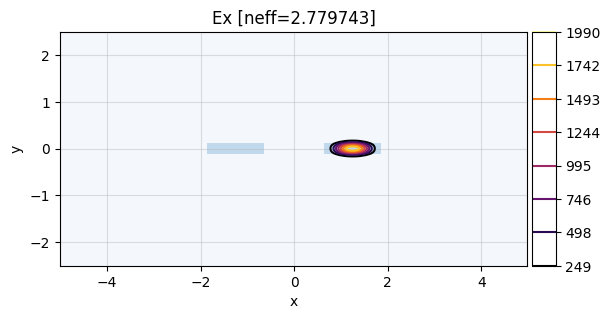

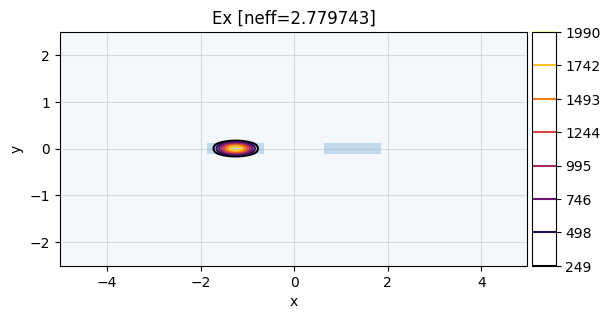

In [3]:
num_modes = 30

modes: list[list[mw.Mode]] = []
for cs in css:
    modes_in_cs = mw.compute_modes(cs, num_modes=num_modes)
    modes.append(modes_in_cs)

def combine_modes(m1, m2):
    return (m1 + m2) / np.sqrt(2), (m1 - m2) / np.sqrt(2) 

mode_p, mode_m = combine_modes(modes[2][0], modes[2][1])

mw.visualize(mode_p, fields=["Ex"])
mw.visualize(mode_m, fields=["Ex"])

We also need to verify how many modes the MMI waveguide supports. Depending on the input mode, many modes can be excited, therefore we need to take in account all of them.

> Symmetry can be used to reduce the number of modes of interest, however, currently, MEOW does not support that 

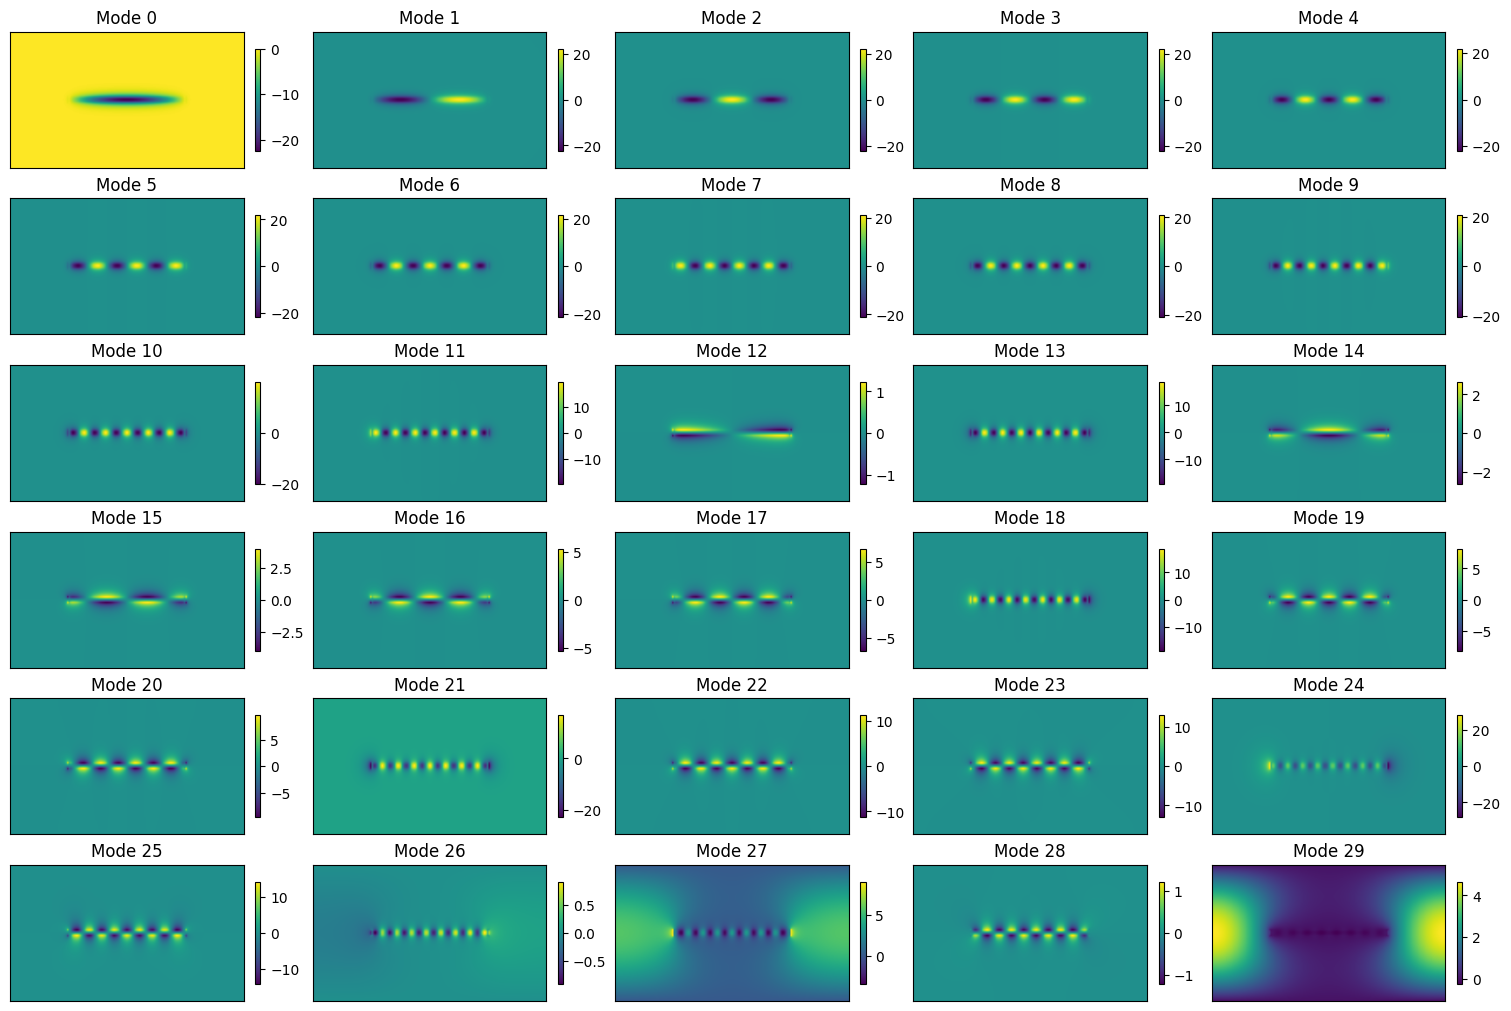

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(6, 5, figsize=(15, 10), constrained_layout=True)

axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(modes[1]):
        im = ax.imshow(np.real(modes[1][i].Ex.T), origin="lower", aspect="auto")
        ax.set_title(f"Mode {i}")
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, shrink=0.75)
    else:
        ax.axis("off")



Now, this is where EME is needed. We need to introduce propagation of the modes for each cell and calculate the overlaps forward and backward.

Let us first test on the initial structure

{'left@0': 0, 'right@0': 1, 'right@1': 2}


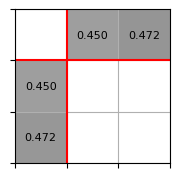

In [36]:
selected_modes = modes.copy()
selected_modes[0] = modes[0][:1]
selected_modes[-1] = modes[-1][:2]
S, port_map = mw.compute_s_matrix(selected_modes, cells=cells)
print(port_map)
mw.visualize((abs(S) ** 2, port_map))

Now, we sweep the length only of the cell of interest, the one containing the MMI waveguide

In [31]:
mmi_lengths = np.arange(5, 600, 1)

selected_modes = modes.copy()
selected_modes[0] = modes[0][:1]
selected_modes[-1] = modes[-1][:2]

s21, s31 = [], []
for mmi_length in mmi_lengths:
    cell_lengths = [1, mmi_length, 1]
    S, pm = mw.compute_s_matrix(selected_modes, cell_lengths=cell_lengths)
    s21.append(S[1, 0])
    s31.append(S[2, 0])

s21, s31 = np.asarray(s21), np.asarray(s31)

### Analysis

We can apply the linear combination also with the S-values.

Let us identify the estimated transmission of the modes and the phase difference between the two

Text(0, 0.5, 'Phase difference')

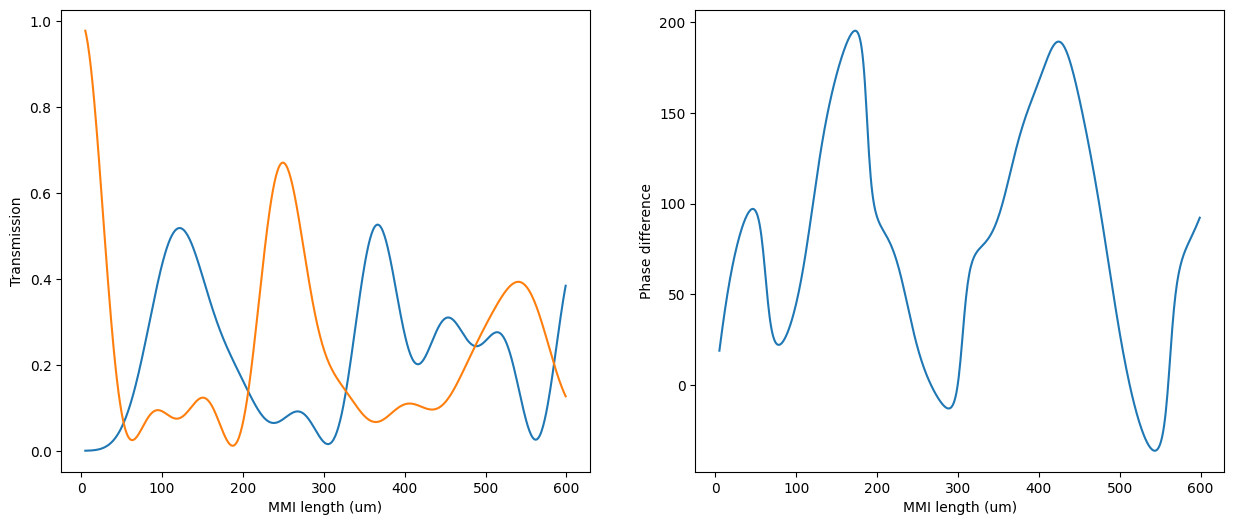

In [45]:
import matplotlib.pyplot as plt

def mag(v):
    return np.abs(v) ** 2

s_p, s_m = combine_modes(s21, s31)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(mmi_lengths, mag(s_p))
axes[0].plot(mmi_lengths, mag(s_m))
axes[0].set_xlabel("MMI length (um)")
axes[0].set_ylabel("Transmission")

axes[1].plot(mmi_lengths, np.rad2deg(np.abs(np.unwrap(np.angle(s_p)) - np.unwrap(np.angle(s_m)))) - 90)
axes[1].set_xlabel("MMI length (um)")
axes[1].set_ylabel("Phase difference")
# axes[1].plot(mmi_lengths, np.unwrap(np.angle(s_m)))




> These results are inconsistent with Lumerical EME mode solver. The MEOW solver needs to be verified

Assuming that the results are correct, we continue with the analysis by finding where the two magnitudes are equal

In [47]:
import numpy as np

def find_crossings(y1, y2, x=None):
    """
    Find where two 1D arrays cross.

    Returns:
        indices: indices i where crossing happens between i and i+1
        x_cross: interpolated x positions of crossings
    """
    y1 = np.asarray(y1)
    y2 = np.asarray(y2)

    if y1.shape != y2.shape:
        raise ValueError(f"y1 and y2 must have same shape, got {y1.shape} and {y2.shape}")

    if y1.ndim != 1:
        raise ValueError("This function expects 1D arrays")

    if x is None:
        x = np.arange(len(y1))
    else:
        x = np.asarray(x)
        if x.shape != y1.shape:
            raise ValueError(f"x must have same shape as y arrays, got {x.shape}")

    d = np.abs(y1 - y2)

    # crossings between points
    crossing_indices = np.where(np.isclose(d, 0, rtol=5e-2, atol=0.5e-2))[0]

    

    return crossing_indices, x[crossing_indices]

find_crossings(mag(s_p), mag(s_m), mmi_lengths)


(array([322, 481, 482, 483]), array([327, 486, 487, 488]))

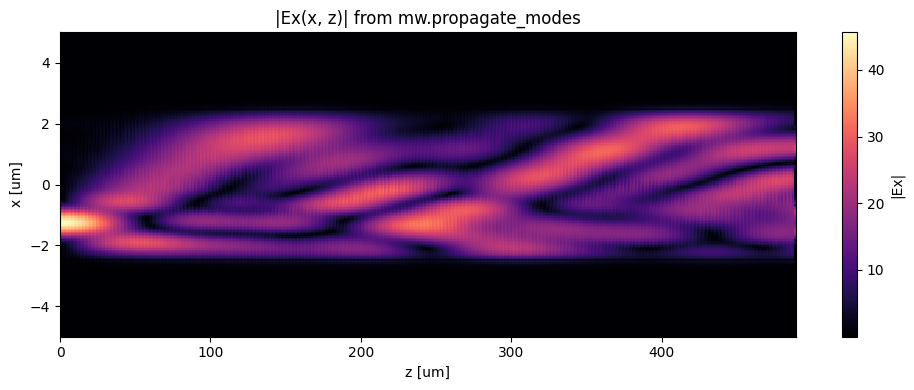

In [50]:


selected_length = mmi_lengths[482]


propagate_cells = mw.create_cells(
    structures=structures,
    mesh=mw.Mesh2D(
        x=np.linspace(-Lx/2, Lx/2, 201),
        y=np.linspace(-Ly/2, Ly/2, 201),
        
    ),
    Ls=np.array([1, selected_length, 1]),
)

z = np.linspace(propagate_cells[0].z_min, propagate_cells[-1].z_max, 1000)
y = 0.0

field, x = mw.propagate_modes(modes, propagate_cells, y=y, z=z)
# print(field.shape, x.shape)
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(z, x, np.abs(field).T, shading="auto", cmap="magma")
ax.set_xlabel("z [um]")
ax.set_ylabel("x [um]")
ax.set_title("|Ex(x, z)| from mw.propagate_modes")
plt.colorbar(im, ax=ax, label="|Ex|")
plt.tight_layout()

### Final results

We are now interested in extracting the figure of merits. For an MMI2x2 these are
- Insertion loss $IL = -10 \log(|S_{21}|^2 + |S_{31}|^2)$
- Excess loss $EL = IL - 3$
- Power imbalance $= 10 \log(|S_{21}|^2 - |S_{31}|^2)$
- Phase imbalance $= |\angle(S_{21}) - \angle(S_{31})| - \pi/2$

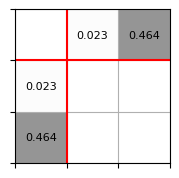

{'T1': np.float64(0.24361053422687473),
 'T2': np.float64(0.2433298437354002),
 'IL': np.float64(3.1252421148998306),
 'EL': np.float64(0.12524211489983061),
 'PowerImbalance': np.float64(-35.51772299050945),
 'PhaseImbalance': np.float64(64.93492744479431)}

In [54]:
def lin2db(x):
    return 10 * np.log10(np.abs(x))

cell_lengths = [1, selected_length, 1]
S, pm = mw.compute_s_matrix(selected_modes, cell_lengths=cell_lengths)
mw.visualize((abs(S) ** 2, port_map))

s_p, s_m = combine_modes(S[1,0], S[2,0])
T1 = mag(s_p)
T2 = mag(s_m)
# mag(s_p), mag(s_m)
out = dict(
    T1 = T1,
    T2 = T2,
    IL = -lin2db(T1 + T2),
    EL = -lin2db(T1 + T2) - 3,
    PowerImbalance = lin2db(T1-T2),
    PhaseImbalance = np.abs(np.rad2deg(np.angle(s_p) - np.angle(s_m))) - 90,
)
out

## Silicon nitride bend

Let us now consider a silicon nitride bend with a propagation loss of $\alpha$ = 0.1 dB/cm

We want to minimize the radius while keeping the total bend loss acceptable. 

To eliminate one source of loss, being the mode overlap mismatch between straight waveguides and bent waveguide, we will recur to partial Euler bends


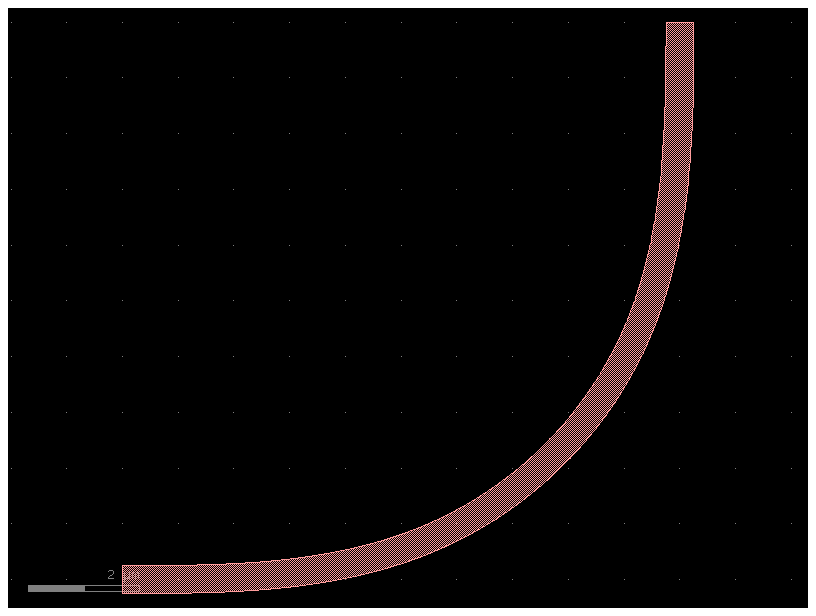

In [1]:
import gdsfactory as gf

gf.gpdk.PDK.activate()

c = gf.components.bend_euler()
c

### Mode simulation of the waveguide

One way to analyze the bend is exploiting the **conformal mapping** technique, used in mode solver simulations.
The conformal mapping will modify the geometry of the simulation by a change of coordinates, and it allows to observe the mode bending.

From now on, we will ignore the overlap mismatch loss, which, for an Euler bend, is negligible, as long as the evolution is adiabatic across the path.

What we want to simulate the variation of the *complex effective index* for varying radii $R$ of a rectangular waveguide under conformal mapping using Perfectly Matched Layer (PML).

$$
n_{eff}(R) = n'(R) + j n''(R)
$$

In particular, we are interested in the imaginary part of the effective index, which will give us
$$
\alpha_R (R) = \frac{4\pi}{\lambda_0} n''

$$
Because of the bending, an increasing amount of the field will shift outward of the waveguide toward the boundaries. The absorption of the PML will estimate the amount of radiation that is lost for bend.


In [2]:
# standard python imports
import matplotlib.pylab as plt
import numpy as np

# tidy3D import
import tidy3d as td
from tidy3d.plugins import waveguide
from tidy3d.constants import C_0

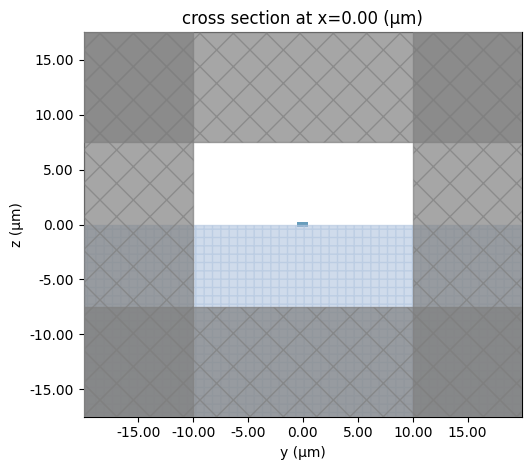

In [73]:
td.config.logging_level = "ERROR"

# function to define the mode solver
def mode_solver_SiN_wvg(
    wg_size=(1., 0.4),
    wavelength=1.55,
    resolution=10,
    npml=12,
    delta_override=None,
    size=(20, 15),
    num_modes=10,
    target_neff=None,
    bend_radius=None,
    bend_axis=1,
    symmetry=(0, 0, 1),
    # fields=["Ex", "Ey", "Ez"],
):
    siN = td.Medium(permittivity=1.996**2)
    sio2 = td.Medium(permittivity=1.44**2)

    structures = [td.Structure(geometry=td.Box(size=(100, 1, 0.4)), medium=siN)]

    mode_spec = td.ModeSpec(
        num_modes=num_modes,
        target_neff=target_neff,
        precision="double",
        bend_radius=bend_radius,
        bend_axis=bend_axis,
        num_pml=(npml, npml),
        group_index_step=True,
        # track_freq=
    )

    if delta_override:
        mesh_override = [
            td.MeshOverrideStructure(
                geometry=td.Box(center=(0, 0, 0), size=(0, 2 * 0.6, 2 * 0.22)),
                dl=(delta_override,) * 3,
            )
        ]
    else:
        mesh_override = []

    grid_spec = td.GridSpec.auto(
        min_steps_per_wvl=resolution, 
        wavelength=wavelength, 
        override_structures=mesh_override
    )

    sim = td.Simulation(
        size=(10, size[0], size[1]),
        center=(0, 0, 0),
        grid_spec=grid_spec,
        structures=structures,
        sources=[],
        monitors=[],
        run_time=1e-12,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        symmetry=symmetry,
        medium=sio2,
    )

    plane = td.Box(center=(0, 0, 0), size=(0, size[0], size[1]))

    mode_solver = td.ModeSimulation.from_simulation(
        simulation=sim,
        plane=plane,
        mode_spec=mode_spec,
        freqs=[td.C_0 / wavelength],
        # fields=fields,
    )

    return mode_solver

ms = mode_solver_SiN_wvg(10, 12)
ms.plot(x=0)
plt.show()

Because of the conformal mapping, the refractive index will increase toward the boundaries, making it harder to identify the mode inside the waveguide.
It is thus necessary to find a criterion or to track it.

The easiest way is to perform a simulation without the bend, find the $n_{eff}$ of the fundamental mode and track it for the the next iterations.

In [4]:
# function to decide if a mode is a valid solution
def isMode(mode_data, mode_index, radius=1, freq_index=0):
    E = abs(mode_data.Ex**2 + mode_data.Ey**2 + mode_data.Ez**2)[0, :, :, freq_index, mode_index]
    center = (
        E.y.min() + (E.y.max() - E.y.min()) / 2,
        E.z.min() + (E.z.max() - E.z.min()) / 2,
    )

    bmInside = (abs(E.y) < (center[0] + radius)) & (abs(E.z) < (center[1] + radius))

    if E.values[bmInside].sum() > E.values[~bmInside].sum():
        return True
    else:
        return False


# function to find the first valid mode
def findMode(mode_data, radius=1):
    for i in range(mode_data.Ex.shape[-1]):
        if isMode(mode_data, i, radius):
            return i
    return None

We then sweep the radius enough to create a radiative loss model

In [74]:
# td.config.logging_level = True

radius = np.arange(15, 75, 10)
data = []
loss = []
for r in radius:
    mode_solver = mode_solver_SiN_wvg(
        resolution=10,
        npml=12,
        num_modes=5,
        target_neff=1.678,
        bend_radius=r,
        bend_axis=1,
        size=(20, 15),
    )

    sim_data = mode_solver.run_local()
    data.append(sim_data)
    mode_data = sim_data.modes

    idx = findMode(mode_data, 0.4)

    l = mode_data.to_dataframe().iloc[idx]['loss (dB/cm)']
    loss.append(l)



c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tid

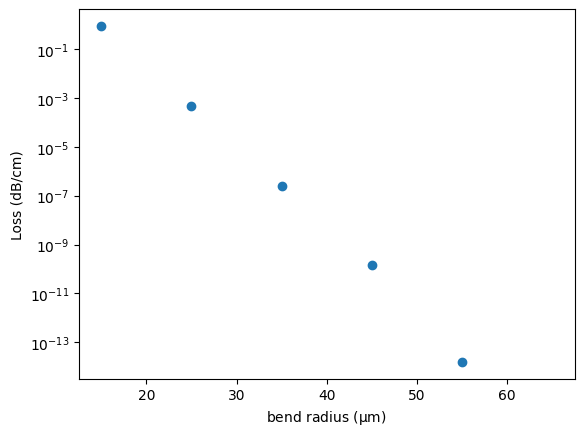

In [58]:
fig, ax = plt.subplots()
ax.plot(radius, loss, "o")
ax.set_yscale("log")
ax.set_xlabel("bend radius ($\\mu$m)")
ax.set_ylabel("Loss (dB/cm)")
plt.show()

In [98]:
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator


def calculate_overlaps(modes1, modes2, f_index=0):
    """Return |overlap|^2 matrix between two mode sets."""
    return np.abs(modes1.outer_dot(modes2).isel(f=f_index).values) ** 2


def max_mode_overlap(modes1, modes2, f_index=0):
    """Return maximum |overlap|^2 between two mode sets."""
    ovp = calculate_overlaps(modes1, modes2, f_index=f_index)
    return np.nanmax(ovp)


def build_overlap_table(
    radii,
    data,
    *,
    f_index=0,
    symmetrize=True,
):
    """
    Build pairwise maximum-overlap table versus radius.

    Parameters
    ----------
    radii : array-like
        Radius values corresponding to data entries.
    data : list
        List of objects where data[i].modes contains modes at radii[i].
    f_index : int
        Frequency index to use.
    symmetrize : bool
        If True, enforce eta(R1, R2) = eta(R2, R1).

    Returns
    -------
    result : dict
        Contains overlap matrix, mismatch matrix, dB mismatch matrix,
        and a long-form dataframe.
    """

    radii = np.asarray(radii, dtype=float)
    n = len(radii)

    if len(data) != n:
        raise ValueError("radii and data must have the same length.")

    eta = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(n):
            eta[i, j] = max_mode_overlap(
                data[i].modes,
                data[j].modes,
                f_index=f_index,
            )

    # Numerical cleanup
    eta = np.clip(eta, 0.0, 1.0)

    if symmetrize:
        eta = 0.5 * (eta + eta.T)

    mismatch = 1.0 - eta

    with np.errstate(divide="ignore"):
        mismatch_dB = -10 * np.log10(np.maximum(eta, 1e-300))

    rows = []
    for i, r1 in enumerate(radii):
        for j, r2 in enumerate(radii):
            rows.append(
                {
                    "R1": r1,
                    "R2": r2,
                    "max_overlap": eta[i, j],
                    "mismatch": mismatch[i, j],
                    "mismatch_dB": mismatch_dB[i, j],
                }
            )

    df = pd.DataFrame(rows)

    return {
        "radii": radii,
        "overlap": eta,
        "mismatch": mismatch,
        "mismatch_dB": mismatch_dB,
        "df": df,
    }

In [101]:
radii = np.array([5, 7.5, 10, 15, 20, 30, 50, 75, 100])

overlap_data = build_overlap_table(
    radii=radius,
    data=data,
    f_index=0,
)

overlap_data["df"]

,R1,R2,max_overlap,mismatch,mismatch_dB
0,15.0,15.0,1.000000,0.000000,-0.000000
1,15.0,25.0,0.997178,0.002822,0.012273
2,15.0,35.0,0.994711,0.005289,0.023031
3,15.0,45.0,0.993026,0.006974,0.030393
4,15.0,55.0,0.991840,0.008160,0.035582
5,15.0,65.0,0.990968,0.009032,0.039403
6,25.0,15.0,0.997178,0.002822,0.012273
7,25.0,25.0,1.000000,0.000000,-0.000000
8,25.0,35.0,0.999584,0.000416,0.001807
9,25.0,45.0,0.999007,0.000993,0.004317


### Analytical model
Once we have the simulation data, we can continue analytically.

Let us use the simulation results to create a fitting model of the radiative loss function.
From the conformal map theory, it is known that the radiative bending loss scales exponentially with the radius
$$
\alpha_{rad}(R) = A e ^ {-B R}
$$

151672.46684774282 0.783373959666557


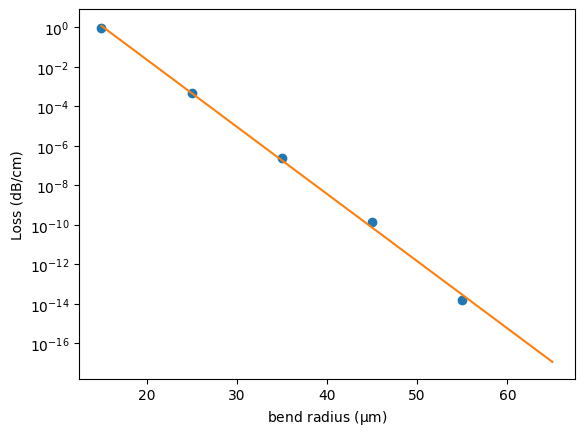

In [16]:
import numpy as np
from scipy.optimize import curve_fit


def loss_exp(R, A, B):
    """
    Simple exponential bend-loss model.

    R: bend radius
    A: loss scale
    B: exponential decay rate
    """
    return A * np.exp(-B * R)


def fit_loss_exp(R, loss):
    R = np.asarray(R, dtype=float)
    loss = np.asarray(loss, dtype=float)

    mask = np.isfinite(R) & np.isfinite(loss) & (loss > 0)
    R_fit = R[mask]
    loss_fit = loss[mask]

    # Fit in log-space for stability
    y = np.log(loss_fit)

    def log_model(R, logA, B):
        return logA - B * R

    popt, pcov = curve_fit(log_model, R_fit, y)
    logA, B = popt

    A = np.exp(logA)

    return {
        "A": A,
        "B": B,
        "cov": pcov,
        "model": lambda R_new: loss_exp(np.asarray(R_new), A, B),
    }


fit = fit_loss_exp(radius, loss)

R_smooth = np.linspace(min(radius), max(radius), 300)
loss_smooth = fit["model"](R_smooth)

print(fit["A"], fit["B"])


fig, ax = plt.subplots()
ax.plot(radius, loss, "o")
ax.plot(R_smooth, loss_smooth)
ax.set_yscale("log")
ax.set_xlabel("bend radius ($\\mu$m)")
ax.set_ylabel("Loss (dB/cm)")
plt.show()

Once we have the fitting model, we can consider a path with a varying curvature like an Euler bend and associate at each point of the curve a position-dependent loss. 

Let us assume we have a curve $\textbf{r}(s)$ with $s$ being the arc-length parametrization. The position-dependent loss on the curve can be defined as

$$
\alpha_{rad}(s) = \alpha_{rad}(1/\kappa(s))
$$
with $\kappa=1/R$ being the local curvature.



70.686


Text(0, 0.5, 'Curvature')

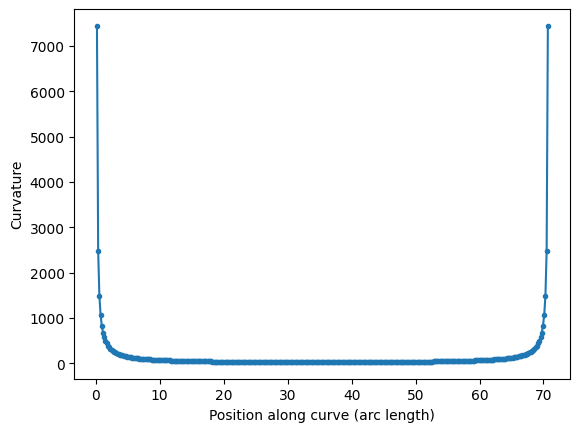

In [ ]:
import gdsfactory as gf

p = gf.path.euler(radius=30, p=0.5)
s, K = p.curvature()

print(p.length())
plt.plot(s, 1/K, ".-")
plt.xlabel("Position along curve (arc length)")
plt.ylabel("Radius of Curvature")

np.float64(7.049814747373324)

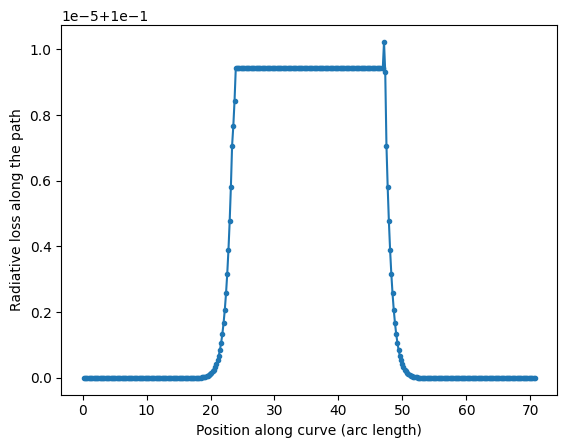

In [29]:
rho = 1 / K
alpha_propagation = 0.1  # dB/cm
alpha_rho = fit["model"](rho)
total_alpha = alpha_propagation + alpha_rho

plt.plot(s, total_alpha, ".-")
plt.xlabel("Position along curve (arc length)")
plt.ylabel("Radiative loss along the path")

total_loss = np.trapezoid(total_alpha, s)
total_loss

Once the position-dependent loss is computed, we can also add the constant intrinsic propagation loss $\alpha_{prop}$ of the waveguide.
The total bend loss will be the path-integral of the loss function over the bend curve

$$
\text{BendLoss} = \int_0^L \left(\alpha_{rad}\left(\frac{1}{\kappa(s)}\right) + \alpha_{prop}\right) ds
$$
with $L$ being the total length of the curve

In [53]:
import numpy as np
import pandas as pd
import gdsfactory as gf


def compute_euler_loss(
    radius,
    p_value,
    fit,
    *,
    alpha_propagation=0.1, # dB/cm
    angle=90,
    use_eff=False,
    npoints=720,
    min_curvature=1e-12,
):
    """
    Compute total loss for one gdsfactory Euler bend.

    Parameters
    ----------
    radius : float
        Euler bend radius passed to gf.path.euler.
    p_value : float
        Euler p parameter passed to gf.path.euler.
    fit : dict
        Fit result containing fit["model"](rho), where rho is bend radius.
        The model should return bend loss per unit length in the same
        units as alpha_propagation.
    alpha_propagation : float
        Propagation loss per unit length.
    angle : float
        Bend angle in degrees.
    use_eff : bool
        Passed to gf.path.euler.
    npoints : int
        Number of points used in the Euler path.
    min_curvature : float
        Curvature below this is treated as straight, with infinite radius.

    Returns
    -------
    dict
        Summary of the bend loss calculation.
    """

    path = gf.path.euler(
        radius=radius,
        p=p_value,
        angle=angle,
        use_eff=use_eff,
        npoints=npoints,
    )

    s, K = path.curvature()
    s = np.asarray(s, dtype=float)
    K = np.asarray(K, dtype=float)

    abs_K = np.abs(K)

    rho = np.full_like(abs_K, np.inf)
    bend_mask = abs_K > min_curvature
    rho[bend_mask] = 1 / abs_K[bend_mask]

    alpha_rho = np.zeros_like(s)
    alpha_rho[bend_mask] = fit["model"](rho[bend_mask])

    total_alpha = alpha_propagation + alpha_rho

    propagation_loss = np.trapezoid(
        np.full_like(s, alpha_propagation) * 1e-4,
        s,
    )
    bend_loss = np.trapezoid(alpha_rho * 1e-4, s)
    total_loss = np.trapezoid(total_alpha * 1e-4, s)

    return {
        "radius": radius,
        "p": p_value,
        "angle": angle,
        "use_eff": use_eff,
        "npoints": npoints,
        "length": s[-1] - s[0],
        "min_rho": np.nanmin(rho[np.isfinite(rho)]),
        "max_curvature": np.nanmax(abs_K),
        "propagation_loss": propagation_loss,
        "bend_loss": bend_loss,
        "total_loss": total_loss,
    }


def sweep_euler_loss(
    radii,
    p_values,
    fit,
    *,
    alpha_propagation=0.1,
    angle=90,
    use_eff=False,
    npoints=720,
    min_curvature=1e-12,
):
    """
    Sweep Euler bend radius and p parameter, returning a pandas DataFrame.
    """

    rows = []

    for radius in radii:
        for p_value in p_values:
            row = compute_euler_loss(
                radius=radius,
                p_value=p_value,
                fit=fit,
                alpha_propagation=alpha_propagation,
                angle=angle,
                use_eff=use_eff,
                npoints=npoints,
                min_curvature=min_curvature,
            )
            rows.append(row)

    return pd.DataFrame(rows)

We can now finally sweep the radii and the value of $p$ that represent the fraction of the partial Euler bend

In [54]:
radii = np.arange(10, 100, 1)
p_values = np.linspace(0.1, 1.0, 10)

df = sweep_euler_loss(
    radii=radii,
    p_values=p_values,
    fit=fit,
    alpha_propagation=0.1,  # same units as fit["model"]
    angle=90,
    npoints=720,
)

df.head()

,radius,p,angle,use_eff,npoints,length,min_rho,max_curvature,propagation_loss,bend_loss,total_loss
0,10,0.1,90,False,720,17.266676,9.993626,0.100064,0.000173,0.086894,0.087067
1,10,0.2,90,False,720,18.836410,9.998264,0.100017,0.000188,0.079411,0.079600
2,10,0.3,90,False,720,20.406114,9.997128,0.100029,0.000204,0.071928,0.072132
3,10,0.4,90,False,720,21.975822,9.997970,0.100020,0.000220,0.064445,0.064664
4,10,0.5,90,False,720,23.545547,9.996506,0.100035,0.000235,0.056961,0.057197


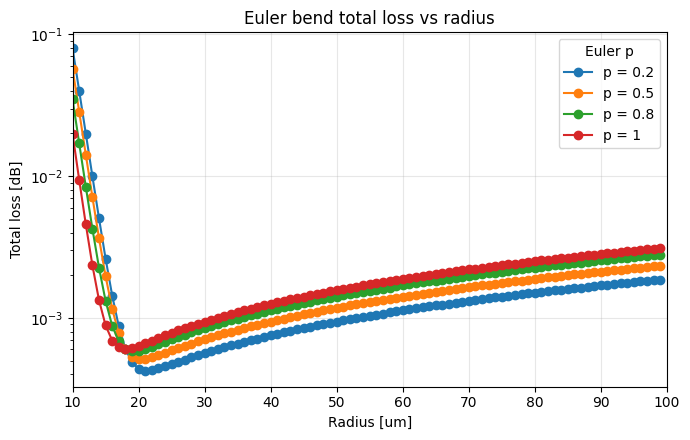

In [55]:


fig, ax = plt.subplots(figsize=(7, 4.5))

p_selected = [0.2, 0.5, 0.8, 1.0]

for p_value, group in df.groupby("p"):
    if p_value in p_selected:
        group = group.sort_values("radius")

        ax.plot(
            group["radius"],
            group["total_loss"],
            marker="o",
            label=f"p = {p_value:g}",
        )

ax.set_yscale('log')
ax.set_xlabel(f"Radius [um]")
ax.set_xlim([10, 100])
ax.set_ylabel(f"Total loss [dB]")
ax.set_title("Euler bend total loss vs radius")
ax.grid(True, alpha=0.3)
ax.legend(title="Euler p")
plt.tight_layout()